In [54]:
!pip install scapy pandas matplotlib seaborn -q


In [55]:
from google.colab import files

uploaded = files.upload()  # в диалоге выбери dhcp (1).pcapng
!ls dhcp*.pcap*


Saving dhcp (1).pcapng to dhcp (1) (5).pcapng
'dhcp (1) (1).pcapng'  'dhcp (1) (3).pcapng'  'dhcp (1) (5).pcapng'
'dhcp (1) (2).pcapng'  'dhcp (1) (4).pcapng'  'dhcp (1).pcapng'


In [57]:
from scapy.all import rdpcap, IP, UDP, BOOTP, DHCP
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pcap_file = 'dhcp (1).pcapng'
print("Файл для анализа:", pcap_file)

packets = rdpcap(pcap_file)
print("Всего пакетов в дампе:", len(packets))


Файл для анализа: dhcp (1).pcapng
Всего пакетов в дампе: 4


In [58]:
dhcp_rows = []

for pkt in packets:
    if pkt.haslayer(IP) and pkt.haslayer(UDP) and pkt.haslayer(BOOTP):
        bootp = pkt[BOOTP]
        msg_type = None

        if pkt.haslayer(DHCP):
            opts = pkt[DHCP].options
            for opt in opts:
                if isinstance(opt, tuple) and opt[0] == 'message-type':
                    msg_type = opt[1]
                    break

        dhcp_rows.append({
            'time': float(pkt.time),
            'src_ip': pkt[IP].src,
            'dst_ip': pkt[IP].dst,
            'client_ip': bootp.yiaddr,
            'server_ip': bootp.siaddr,
            'xid': bootp.xid,
            'msg_type': msg_type,
        })

df_dhcp = pd.DataFrame(dhcp_rows)
print("Найдено DHCP-событий:", len(df_dhcp))
df_dhcp.head()


Найдено DHCP-событий: 4


,time,src_ip,dst_ip,client_ip,server_ip,xid,msg_type
0,1.102274e+09,0.0.0.0,255.255.255.255,0.0.0.0,0.0.0.0,15645,1
1,1.102274e+09,192.168.0.1,192.168.0.10,192.168.0.10,192.168.0.1,15645,2
2,1.102274e+09,0.0.0.0,255.255.255.255,0.0.0.0,0.0.0.0,15646,3
3,1.102274e+09,192.168.0.1,192.168.0.10,192.168.0.10,0.0.0.0,15646,5


In [59]:
print("=== DHCP: сводка ===")

if df_dhcp.empty:
    print("DHCP-события не найдены")
else:
    print("\n1. Выданные клиентам IP-адреса:")
    client_counts = df_dhcp['client_ip'].value_counts()
    print(client_counts)

    print("\n2. DHCP-серверы:")
    server_counts = df_dhcp['server_ip'].value_counts()
    print(server_counts)

    print("\n3. Типы DHCP-сообщений (message-type):")
    # 1=DISCOVER, 2=OFFER, 3=REQUEST, 5=ACK и т.п.
    msg_counts = df_dhcp['msg_type'].value_counts().sort_index()
    print(msg_counts)

    print("\n4. Уникальных клиентов:", len(client_counts))
    print("5. Уникальных серверов:", len(server_counts))


=== DHCP: сводка ===

1. Выданные клиентам IP-адреса:
client_ip
0.0.0.0         2
192.168.0.10    2
Name: count, dtype: int64

2. DHCP-серверы:
server_ip
0.0.0.0        3
192.168.0.1    1
Name: count, dtype: int64

3. Типы DHCP-сообщений (message-type):
msg_type
1    1
2    1
3    1
5    1
Name: count, dtype: int64

4. Уникальных клиентов: 2
5. Уникальных серверов: 2


In [60]:
if not df_dhcp.empty:
    df_dhcp['datetime'] = pd.to_datetime(df_dhcp['time'], unit='s')
    df_dhcp['minute'] = df_dhcp['datetime'].dt.floor('T')
    time_counts = df_dhcp.groupby('minute').size()
    time_counts


/tmp/ipykernel_1331/1611057434.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_dhcp['minute'] = df_dhcp['datetime'].dt.floor('T')


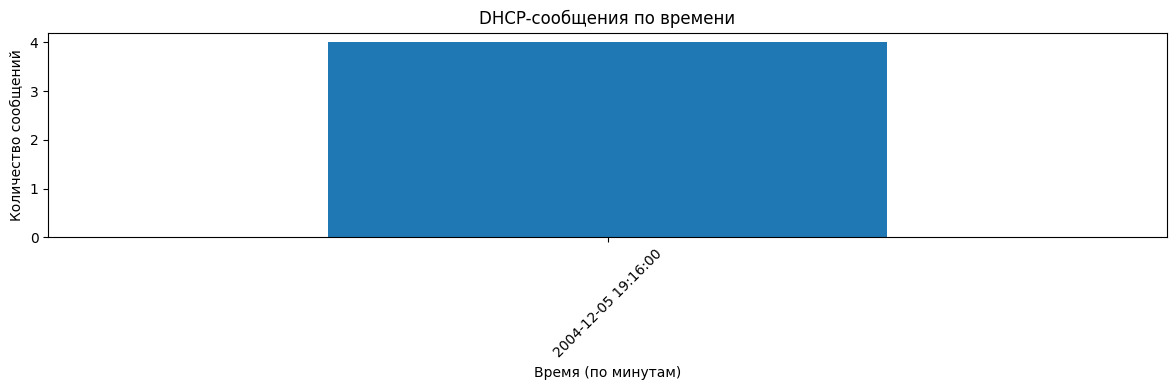

In [61]:
if not df_dhcp.empty:
    plt.figure(figsize=(12, 4))
    time_counts.plot(kind='bar')
    plt.title('DHCP-сообщения по времени')
    plt.xlabel('Время (по минутам)')
    plt.ylabel('Количество сообщений')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


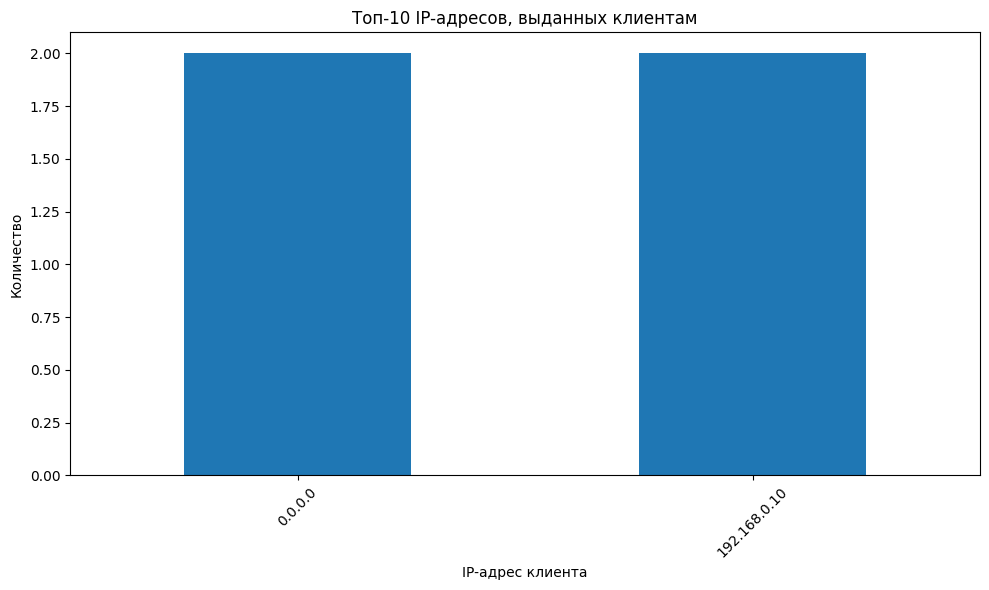

In [62]:
if not df_dhcp.empty:
    plt.figure(figsize=(10, 6))
    client_counts.head(10).plot(kind='bar')
    plt.title('Топ-10 IP-адресов, выданных клиентам')
    plt.xlabel('IP-адрес клиента')
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [63]:
if not df_dhcp.empty:
    df_dhcp.to_csv('dhcp_analysis.csv', index=False)
    print("Файл dhcp_analysis.csv сохранен")

    from google.colab import files
    files.download('dhcp_analysis.csv')
else:
    print("Нет данных для сохранения")


Файл dhcp_analysis.csv сохранен


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>